In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors

import scanpy as sc

import os


import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols



    

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [2]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])



entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)


## Load Fragments overlap CR-called peaks counts 
CR_frag_overlap_CRpeaks_file = os.path.join(entropy_dir, '_CRpipe_peak_frag_overlap_peak', 'overlap_peaks_counts.txt')
CR_frag_overlap_CRpeaks = pd.read_csv(CR_frag_overlap_CRpeaks_file, sep=' ', index_col=1, header=None)
CR_frag_overlap_CRpeaks.columns = ['frag_overlap_CRpeaks']
CR_frag_overlap_CRpeaks.index.name = None
CR_frag_overlap_CRpeaks['atac_bc'] = CR_frag_overlap_CRpeaks.index.map(lambda x: x.split('-1')[0])
CR_frag_overlap_CRpeaks.reset_index(inplace=True, drop=False)
CR_frag_overlap_CRpeaks.set_index('atac_bc', inplace=True)


# ## Load Fragments overlap CR-barcode-called peaks counts 
# CRbcs_peak_frip_file = os.path.join(entropy_dir, 'CR_output', 'fragments_overlap_peaks', 'overlap_peaks_counts.txt')
# CRbcs_peak_frip = pd.read_csv(CRbcs_peak_frip_file, sep=' ', index_col=1, header=None)
# CRbcs_peak_frip.columns = ['frag_overlap_CRbcs_peaks']
# CRbcs_peak_frip.index.name = None
# CRbcs_peak_frip['atac_bc'] = CRbcs_peak_frip.index.map(lambda x: x.split('-1')[0])
# CRbcs_peak_frip.reset_index(inplace=True, drop=False)
# CRbcs_peak_frip.set_index('atac_bc', inplace=True)

In [3]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
if 'total_fragments' in entropy_df.columns:
    entropy_df.drop(columns=['total_fragments'], inplace=True)
if 'Nfrag_overlap_standard_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_standard_peak'], inplace=True)
if 'Nfrag_overlap_entropy_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_entropy_peak'], inplace=True)
    

entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%', 'total_fragments', 'frag_overlap_peaks']].rename(
    columns={'frag_overlap_peaks%': 'standard_peak_FRIP', 'frag_overlap_peaks': 'Nfrag_overlap_standard_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%', 'frag_overlap_entropy_peaks']].rename(
    columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP', 'frag_overlap_entropy_peaks': 'Nfrag_overlap_entropy_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df['total_fragment_log1p'] = np.log1p(entropy_df['total_fragments'])



if 'frag_overlap_CRpeaks' in entropy_df.columns:
    entropy_df.drop(columns=['frag_overlap_CRpeaks'], inplace=True)
    
entropy_df = entropy_df.merge(CR_frag_overlap_CRpeaks[['frag_overlap_CRpeaks']],\
    left_on='atac_bc', right_index=True, how='left')

entropy_df['CRpeak_FRIP'] = entropy_df['frag_overlap_CRpeaks'] / entropy_df['total_fragments'] * 100



In [4]:
entropy_df.head()

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,atac_bc,standard_peak_FRIP,total_fragments,Nfrag_overlap_standard_peak,entropy_peak_FRIP,Nfrag_overlap_entropy_peak,total_fragment_log1p,frag_overlap_CRpeaks,CRpeak_FRIP
AAGCCATAGCTAATAG-1,0.005725,1.069145,11,0.343957,0.708959,0.999545,-2.242193,AAGCCATAGCTAATAG,3.930818,636,25.0,4.559748,29.0,6.456770,37.0,5.817610
CACGGTAAGAATCACA-1,0.004039,1.910865,19,1.377521,0.252203,0.999694,-2.393755,CACGGTAAGAATCACA,3.393214,501,17.0,3.992016,20.0,6.218600,30.0,5.988024
ACTGGCTTCTAACTGT-1,0.013996,2.526995,94,2.283363,0.101941,0.998739,-1.853984,ACTGGCTTCTAACTGT,5.901288,932,55.0,6.330472,59.0,6.838405,75.0,8.047210
TCAGGCTTCTTTGGTG-1,0.004926,1.123864,10,0.376438,0.686302,0.999616,-2.307501,TCAGGCTTCTTTGGTG,4.285714,140,6.0,4.285714,6.0,4.948760,14.0,10.000000
GGTTTACGTCACAGGG-1,0.007795,2.188419,43,1.624756,0.196960,0.999355,-2.108172,GGTTTACGTCACAGGG,3.285421,487,16.0,3.285421,16.0,6.190315,18.0,3.696099


## Load ArchR cell-calling using TSS 

In [5]:
archr_cell_calling_file = os.path.join(entropy_dir, '_ArchR_TSS/archr_qc_df.csv')
archr_Tss_cell_call = pd.read_csv(archr_cell_calling_file)
archr_Tss_cell_call['atac_bc'] = archr_Tss_cell_call['cellNames'].apply(lambda x: x.split('#')[1].split('-')[0])
archr_Tss_cell_call = archr_Tss_cell_call.loc[archr_Tss_cell_call['Keep'] == 1 ]
archr_Tss_cell_call.shape

(2132, 13)

In [6]:
archr_Tss_cell_call.head()

,cellNames,nFrags,nMonoFrags,nDiFrags,nMultiFrags,TSSEnrichment,ReadsInTSS,Keep,ReadsInPromoter,PromoterRatio,ReadsInBlacklist,BlacklistRatio,atac_bc
0,VIB2#GGGTTGCAGCTCAAGG-1,93652,47018,37344,9290,20.827,61970,1,55796,0.297890,1417,0.007565,GGGTTGCAGCTCAAGG
1,VIB2#GTCATTTAGAGAGCAA-1,92024,24025,55290,12709,12.683,17927,1,17285,0.093916,839,0.004559,GTCATTTAGAGAGCAA
3,VIB2#AAAGCCTAGGATTATG-1,76499,44716,25339,6444,19.119,57719,1,51750,0.338240,971,0.006346,AAAGCCTAGGATTATG
4,VIB2#TATTGTGGTGGATTAG-1,60195,32781,21972,5442,19.352,42150,1,37027,0.307559,763,0.006338,TATTGTGGTGGATTAG
5,VIB2#TCAAGTGCACGCAATA-1,60116,33088,22982,4046,11.516,19227,1,19280,0.160357,1398,0.011628,TCAAGTGCACGCAATA


## Matching RNA and ATAC barcodes

In [7]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 17)

In [8]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])
entropy_df['atac_pass_archr_TSS'] = entropy_df['atac_bc'].isin(archr_Tss_cell_call['atac_bc'])

In [39]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'all' if row['atac_pass_entropy'] and row['atac_pass_CR'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] and not row['atac_pass_archr_TSS'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] and not row['atac_pass_archr_TSS'] else 
                  ('archr_TSS_only' if not row['atac_pass_entropy'] and not row['atac_pass_CR'] and row['atac_pass_archr_TSS'] else 'others')
                )), axis=1
)


entropy_df['_2set_identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

entropy_df['_2set_identified_by_atac_ST'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_archr_TSS'] else 
                 ('tss_only' if not row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 'none')), axis=1
)

In [10]:
entropy_df['identified_by_atac'].value_counts()

identified_by_atac
others            31167
all                1792
archr_TSS_only      180
entropy_only        121
cr_only              27
Name: count, dtype: int64

In [11]:
CR_atacmodality_bc['atac_bc'].shape, 
# This means 1959 - 1946 = 13 barcodes are unique to CR cell-calling do not have valid entropy values 

((1959,),)

In [12]:
entropy_df.loc[entropy_df['identified_by_atac'] == 'cr_only']

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,standard_peak_FRIP,total_fragments,Nfrag_overlap_standard_peak,...,total_fragment_log1p,frag_overlap_CRpeaks,CRpeak_FRIP,atac_bc,rna_barcodes,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,identified_by_atac
atac_barcodes,,,,,,,,,,,,,,,,,,,,,
CCATAAGCATGACAGC,0.038146,2.097790,246,1.308025,0.270354,0.995937,-1.418548,3.129061,10003,313.0,...,9.210740,586.0,5.858243,CCATAAGCATGACAGC,GCTATAGGTCAAGTAT,False,True,False,False,cr_only
GGTCATGAGGTGAATC,0.035308,0.677658,47,0.165642,0.847350,0.996290,-1.452127,40.589888,712,289.0,...,6.569481,308.0,43.258427,GGTCATGAGGTGAATC,GCTAGTGTCCTCATGC,False,True,False,False,cr_only
CTGGACAAGCTTGTTG,0.052713,0.791814,93,0.207858,0.812322,0.994029,-1.278086,71.328671,858,612.0,...,6.755769,664.0,77.389277,CTGGACAAGCTTGTTG,TAATGCATCCCTTGCG,True,True,False,False,cr_only
CGAATATCATGAGCCG,0.023803,1.174906,72,0.464213,0.628630,0.997664,-1.623363,64.688427,674,436.0,...,6.514713,448.0,66.468843,CGAATATCATGAGCCG,TCAGTGAGTAATAGCT,True,True,False,False,cr_only
CTATATCAGCGATATA,0.029794,1.035761,70,0.325256,0.722342,0.996962,-1.525868,56.896552,464,264.0,...,6.142037,303.0,65.301724,CTATATCAGCGATATA,TTCGTGCTCAGTATTG,True,True,False,False,cr_only
GATTCAGCAGGACCTG,0.043180,0.908170,89,0.258535,0.772182,0.995292,-1.364719,66.114180,543,359.0,...,6.298949,378.0,69.613260,GATTCAGCAGGACCTG,TCACCTGGTGAGGTAG,True,True,False,False,cr_only
TACCTGCAGTACTGAA,0.035301,0.616426,41,0.142937,0.866808,0.996291,-1.452215,73.543689,412,303.0,...,6.023448,320.0,77.669903,TACCTGCAGTACTGAA,TAAGCTATCCCTGGTT,True,True,False,False,cr_only
TAGCTAAAGCATCCTA,0.036889,0.907764,74,0.259094,0.771750,0.996093,-1.433097,65.160523,841,548.0,...,6.735780,571.0,67.895363,TAGCTAAAGCATCCTA,TGCAATATCCTTAGGG,True,True,False,False,cr_only
ACGTCAACACGCCCAT,0.030150,0.980160,65,0.293369,0.745747,0.996919,-1.520714,57.553957,834,480.0,...,6.727432,509.0,61.031175,ACGTCAACACGCCCAT,TATGGGCGTAGGTGTC,True,True,False,False,cr_only


In [1]:
225 + 1880

2105

In [35]:
entropy_df.groupby(['rna_pass_CR', 'atac_pass_CR']).size().unstack(fill_value=0)

atac_pass_CR,False,True
rna_pass_CR,,
False,31116,66
True,225,1880


In [36]:
entropy_df.groupby(['rna_pass_CR', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
rna_pass_CR,,
False,31044,138
True,117,1988


In [37]:
entropy_df.groupby(['rna_pass_CR', 'atac_pass_archr_TSS']).size().unstack(fill_value=0)

atac_pass_archr_TSS,False,True
rna_pass_CR,,
False,30955,227
True,210,1895


In [40]:
entropy_df.groupby(['rna_pass_CR', '_2set_identified_by_atac']).size().unstack(fill_value=0)

_2set_identified_by_atac,both,cr_only,entropy_only,none
rna_pass_CR,,,,
False,54,12,84,31032
True,1833,47,155,70


In [42]:
entropy_df.groupby(['rna_pass_CR', '_2set_identified_by_atac_ST']).size().unstack(fill_value=0)

_2set_identified_by_atac_ST,both,entropy_only,none,tss_only
rna_pass_CR,,,,
False,44,94,30861,183
True,1866,122,88,29


# So now let's calcualte those metrics for all BCs -- From loading all the framents file

In [13]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']
frag.head()

,chrom,start,end,support,atac_bc,frag_length
atac_BC,,,,,,
AGTAGGCGTCCATTAA-1,chr1,10067,10198,1,AGTAGGCGTCCATTAA,131
TGAGGCATCATCAGTT-1,chr1,10085,10333,3,TGAGGCATCATCAGTT,248
CCTAACTCATTTCGCG-1,chr1,10090,10309,1,CCTAACTCATTTCGCG,219
CATCACTCAGGTATTG-1,chr1,10091,10327,1,CATCACTCAGGTATTG,236
ACTCCTAAGTCTTAGT-1,chr1,10097,10308,1,ACTCCTAAGTCTTAGT,211


In [14]:
total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
total_frag_per_bc.columns = ['total_fragments']
total_frag_per_bc.head()

,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [16]:
total_frag_per_bc['atac_pass_CR'] = total_frag_per_bc.index.isin(CR_atacmodality_bc['atac_bc'])
total_frag_per_bc['atac_pass_entropy'] = total_frag_per_bc.index.isin(entropy_filtered_bc_df['atac_bc'])
total_frag_per_bc['atac_pass_archr_TSS'] = total_frag_per_bc.index.isin(archr_Tss_cell_call['atac_bc'])

total_frag_per_bc['_2set_identified_by_atac'] = total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

total_frag_per_bc['_2set_identified_by_atac_ST'] = total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_archr_TSS'] else 
                 ('tss_only' if not row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 'none')), axis=1
)

In [17]:

total_frag_per_bc['identified_by_atac'] = total_frag_per_bc.apply(
    lambda row: 'all' if row['atac_pass_entropy'] and row['atac_pass_CR'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] and not row['atac_pass_archr_TSS'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] and not row['atac_pass_archr_TSS'] else 
                  ('archr_TSS_only' if not row['atac_pass_entropy'] and not row['atac_pass_CR'] and row['atac_pass_archr_TSS'] else (
                      'none' if not row['atac_pass_entropy'] and not row['atac_pass_CR'] and not row['atac_pass_archr_TSS'] else '2votes'
                  ))
                )), axis=1
)


In [18]:
# Merge into entropy values and keep the invalid entropy value barcodes as well
if 'Entropy' in total_frag_per_bc.columns:
    total_frag_per_bc.drop(columns=['Entropy'], inplace=True)
total_frag_per_bc = total_frag_per_bc.merge(entropy_df[['Entropy']], left_index=True, right_index=True, how='left') 

In [19]:
total_frag_per_bc.head()

,total_fragments,atac_pass_CR,atac_pass_entropy,_2set_identified_by_atac,atac_pass_archr_TSS,_2set_identified_by_atac_ST,identified_by_atac,Entropy
atac_bc,,,,,,,,
AAACAAGCAAACATGT,4,False,False,none,False,none,none,NaN
AAACAAGCAAACCAGC,1,False,False,none,False,none,none,NaN
AAACAAGCAAACCTAG,207,False,False,none,False,none,none,0.011025
AAACAAGCAAACTAAC,1,False,False,none,False,none,none,NaN
AAACAAGCAAAGAAGC,987,False,False,none,False,none,none,0.011332


In [20]:
total_frag_per_bc['_2set_identified_by_atac'].value_counts()

_2set_identified_by_atac
none            286811
both              1887
entropy_only       239
cr_only             72
Name: count, dtype: int64

In [21]:
total_frag_per_bc['identified_by_atac'] .value_counts()

identified_by_atac
none              286622
all                 1792
2votes               246
archr_TSS_only       189
entropy_only         121
cr_only               39
Name: count, dtype: int64

In [22]:
total_frag_per_bc.head()

,total_fragments,atac_pass_CR,atac_pass_entropy,_2set_identified_by_atac,atac_pass_archr_TSS,_2set_identified_by_atac_ST,identified_by_atac,Entropy
atac_bc,,,,,,,,
AAACAAGCAAACATGT,4,False,False,none,False,none,none,NaN
AAACAAGCAAACCAGC,1,False,False,none,False,none,none,NaN
AAACAAGCAAACCTAG,207,False,False,none,False,none,none,0.011025
AAACAAGCAAACTAAC,1,False,False,none,False,none,none,NaN
AAACAAGCAAAGAAGC,987,False,False,none,False,none,none,0.011332


In [23]:
if 'frag_overlap_CRpeaks' in total_frag_per_bc.columns:
    total_frag_per_bc.drop(columns=['frag_overlap_CRpeaks'], inplace=True)


total_frag_per_bc = total_frag_per_bc.merge(CR_frag_overlap_CRpeaks[['frag_overlap_CRpeaks']], left_index=True, right_index=True, how='left')
total_frag_per_bc['CRpeak_FRIP'] = total_frag_per_bc['frag_overlap_CRpeaks'] / total_frag_per_bc['total_fragments'] * 100




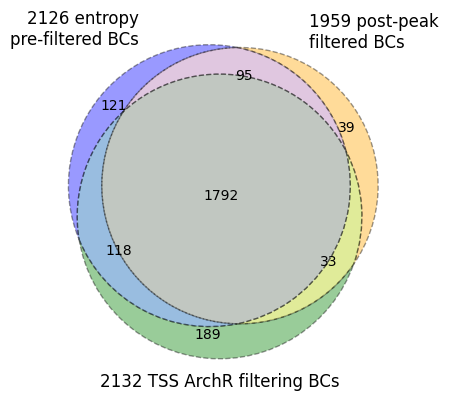

In [24]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'TSS ArchR filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} TSS ArchR filtering BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

### Vis FRIP

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [71.52115430672441, 39.04932109935205, 57.83528387508196, 6.3600169978774685, 57.467556708310944, 25.254077041237682]
median 	 [72.53921585676142, 20.388349514563107, 67.89536266349585, 5.89307411907655, 69.89330024706359, 1.5151515151515151]


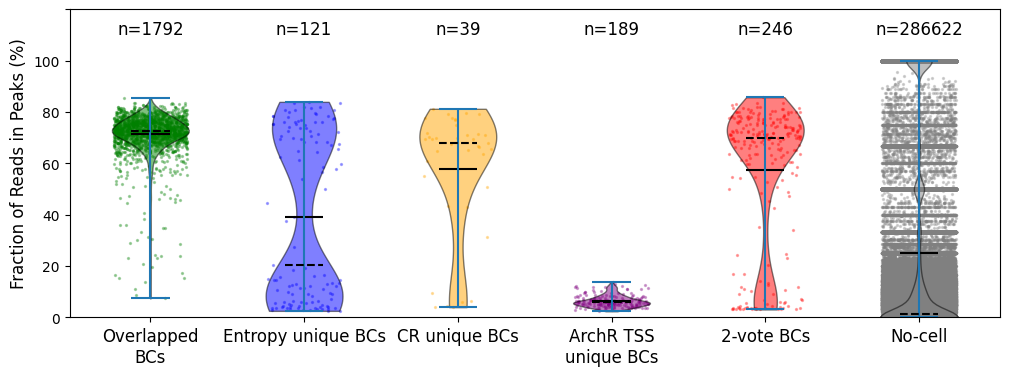

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))

x_positions = range(6)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'purple', 'red', 'gray']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in 
               ['all', 'entropy_only', 'cr_only', 'archr_TSS_only', '2votes', 'none'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy unique BCs', 'CR unique BCs', 'ArchR TSS\nunique BCs', '2-vote BCs', 'No-cell'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

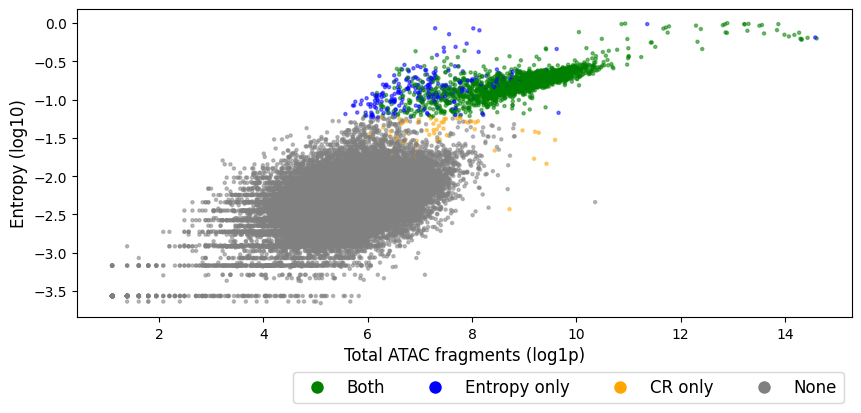

In [ ]:
fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='No-cell',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

plt.show()

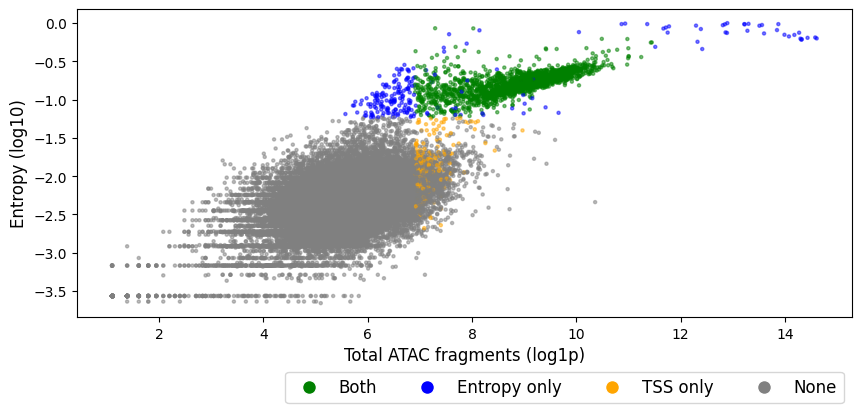

In [ ]:
fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'tss_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac_ST'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='TSS only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='No-cell',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)


plt.show()

### How many barcoeds have invalid entropy values

In [28]:
total_frag_per_bc['invalid_entropy_value'] = ~total_frag_per_bc.index.isin(entropy_df.index)
total_frag_per_bc['invalid_entropy_value'].value_counts()

invalid_entropy_value
True     255722
False     33287
Name: count, dtype: int64

In [29]:
total_frag_per_bc.groupby(['invalid_entropy_value', 'identified_by_atac']).size().unstack()

identified_by_atac,2votes,all,archr_TSS_only,cr_only,entropy_only,none
invalid_entropy_value,,,,,,
False,245.0,1792.0,180.0,27.0,121.0,30922.0
True,1.0,NaN,9.0,12.0,NaN,255700.0


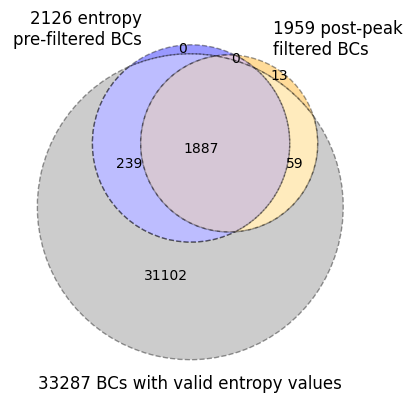

In [30]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()



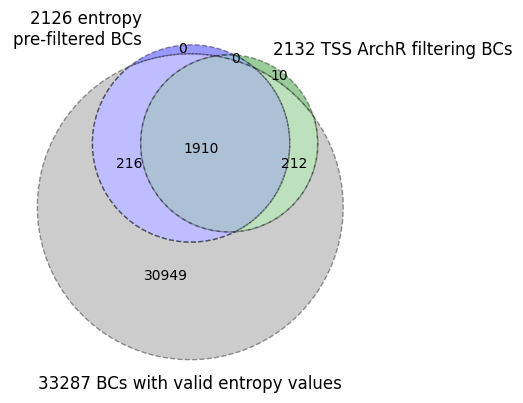

In [31]:

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'TSS ArchR filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} TSS ArchR filtering BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'green', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

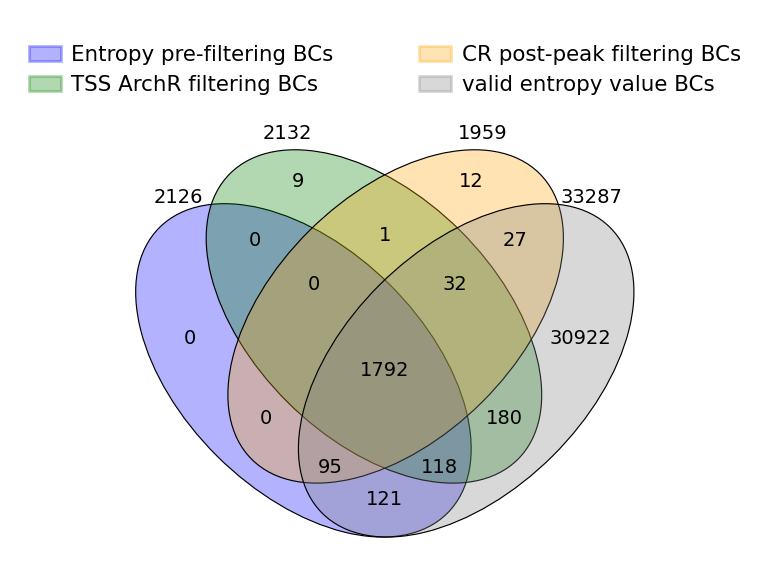

In [32]:
from venny4py.venny4py import *


venn_4sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'TSS ArchR filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)
}


venny4py(sets=venn_4sets, colors=['blue', 'green', 'orange', 'grey'])
plt.show()

### ---

----- 	 both 	 entropy_only 	 tss_only (invalid entropy) 	 tss_only (valid entropy) 	 none
mean 	 [71.355, 40.854, 25.259, 12.67, 14.105]
median 	 [72.54, 46.249, 1.541, 6.524, 6.268]


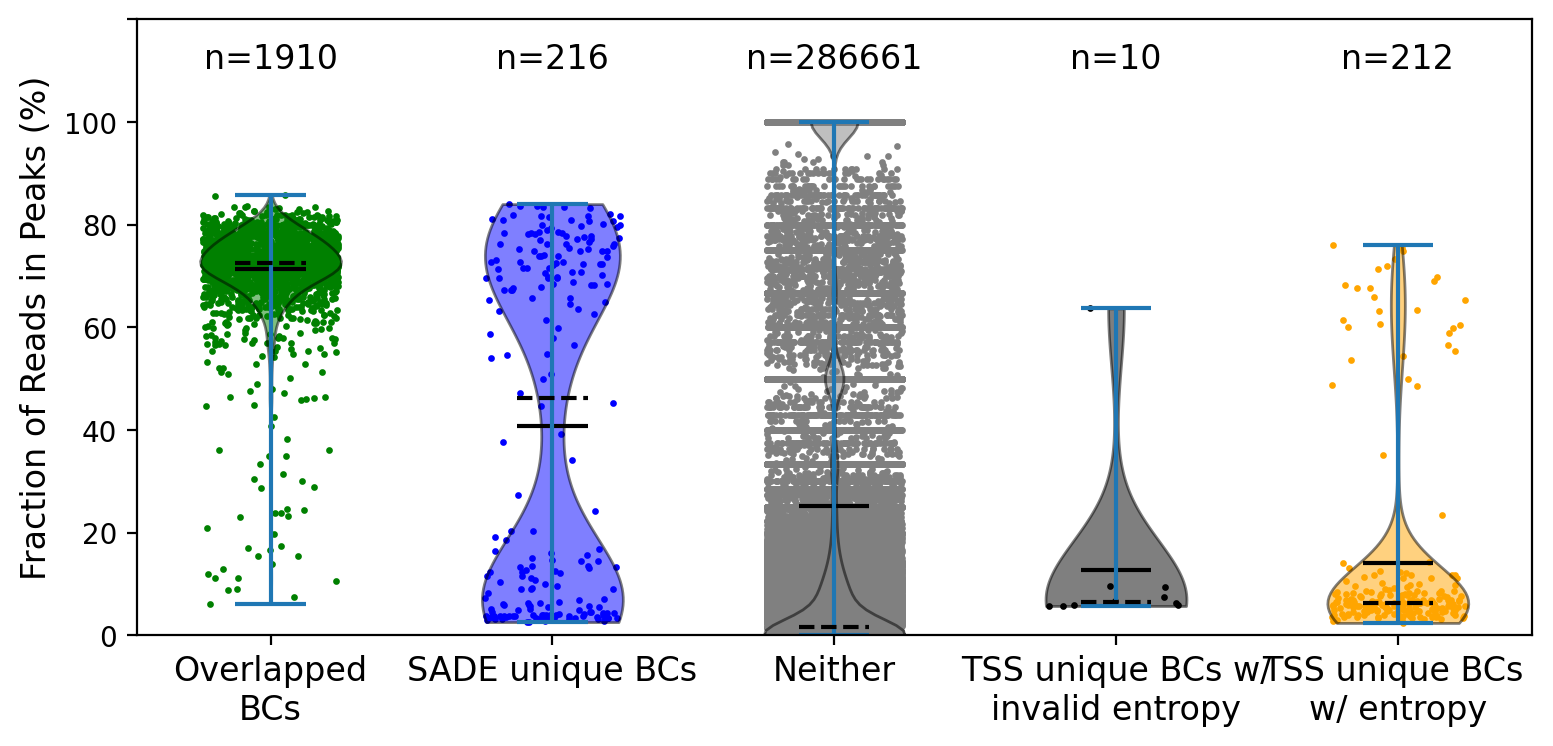

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',   'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'SADE unique BCs', 'Neither', 
                    'TSS unique BCs w/\ninvalid entropy', 'TSS unique BCs \nw/ entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t tss_only (invalid entropy) \t tss_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

----- 	 both 	 entropy_only 	 cr_only (invalid entropy) 	 cr_only (valid entropy) 	 none
mean 	 [70.093, 53.756, 25.242, 72.678, 54.672]
median 	 [72.426, 69.779, 1.695, 70.986, 63.244]


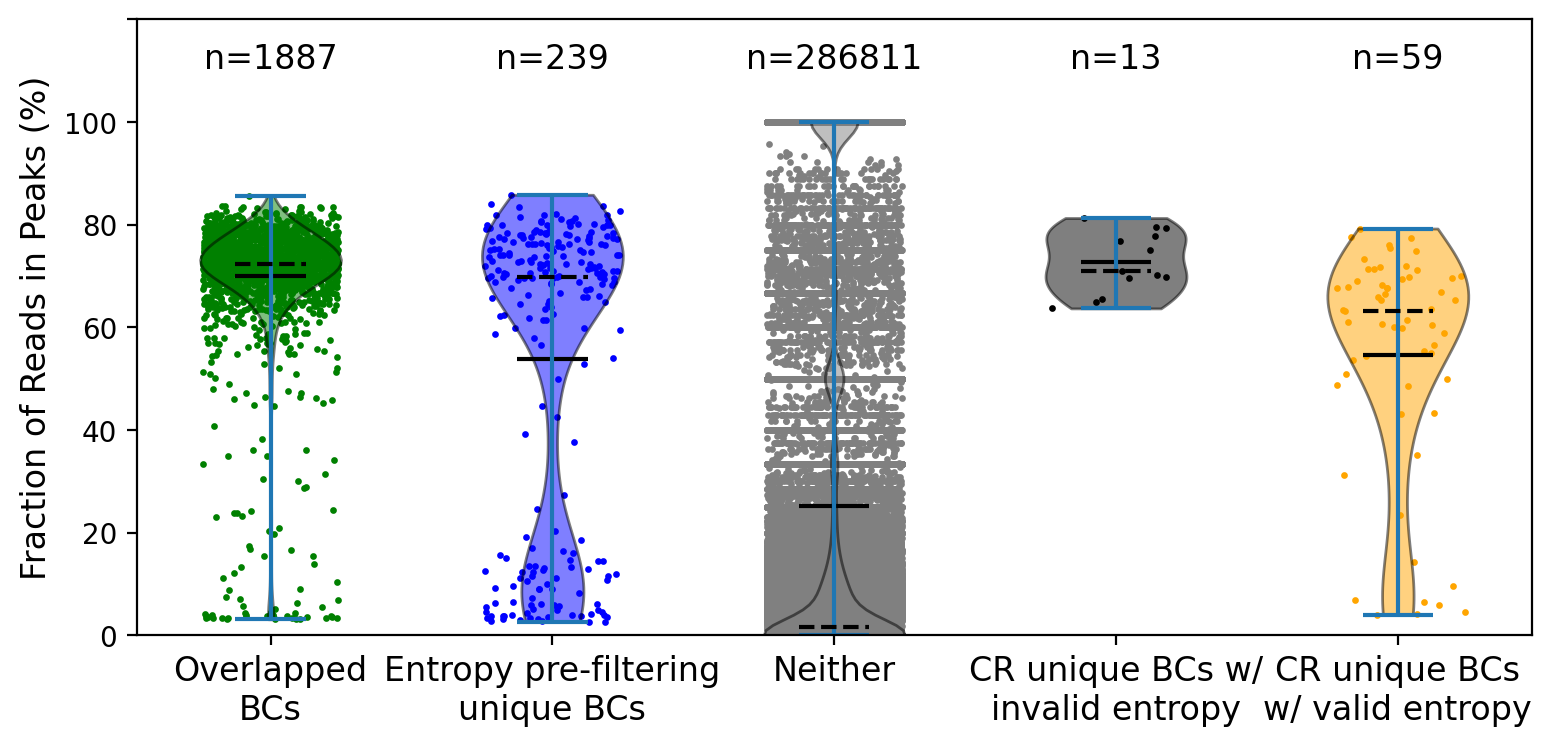

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['_2set_identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',  'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Neither', 
                    'CR unique BCs w/\ninvalid entropy', 'CR unique BCs\nw/ valid entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only (invalid entropy) \t cr_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# Filter fragments by each category BCs

## Between SADE & CR

In [54]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['identified_by_atac'] == 'cr_only')
].index.values
CR_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [55]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'cr_only'
].index.values
CR_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [56]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'cr_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

CR_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [57]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'entropy_only'
].index.values
Entropy_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [58]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'both')
].index.values

Overlap_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

Text(0.5, 1.0, 'CR unique BCs with invalid entropy values')

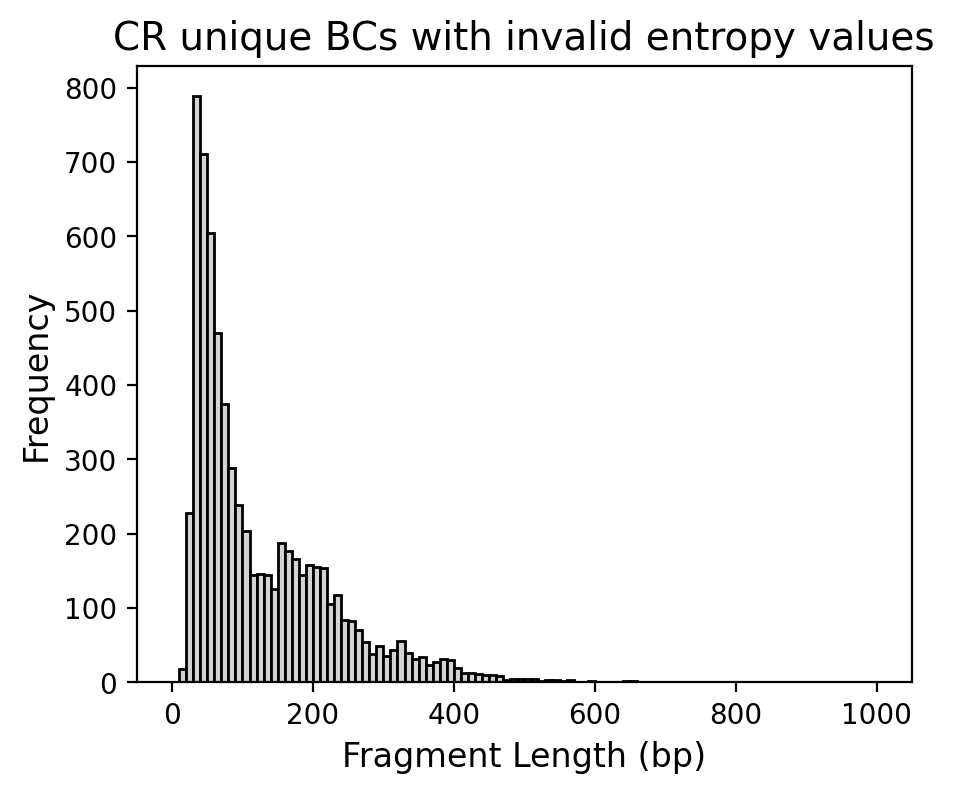

In [59]:


fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR unique BCs with invalid entropy values', fontsize=14)

Text(0.5, 1.0, 'CR unique BCs with valid entropy values')

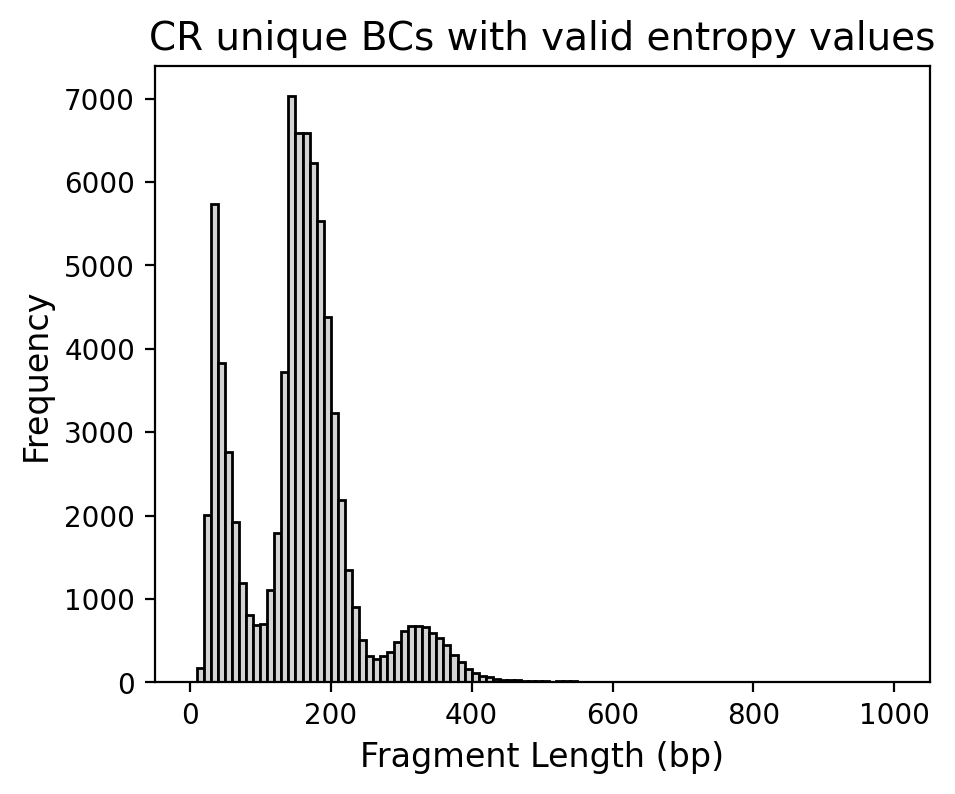

In [60]:

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_validEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR unique BCs with valid entropy values', fontsize=14)

Text(0.5, 1.0, 'Entropy unique BCs')

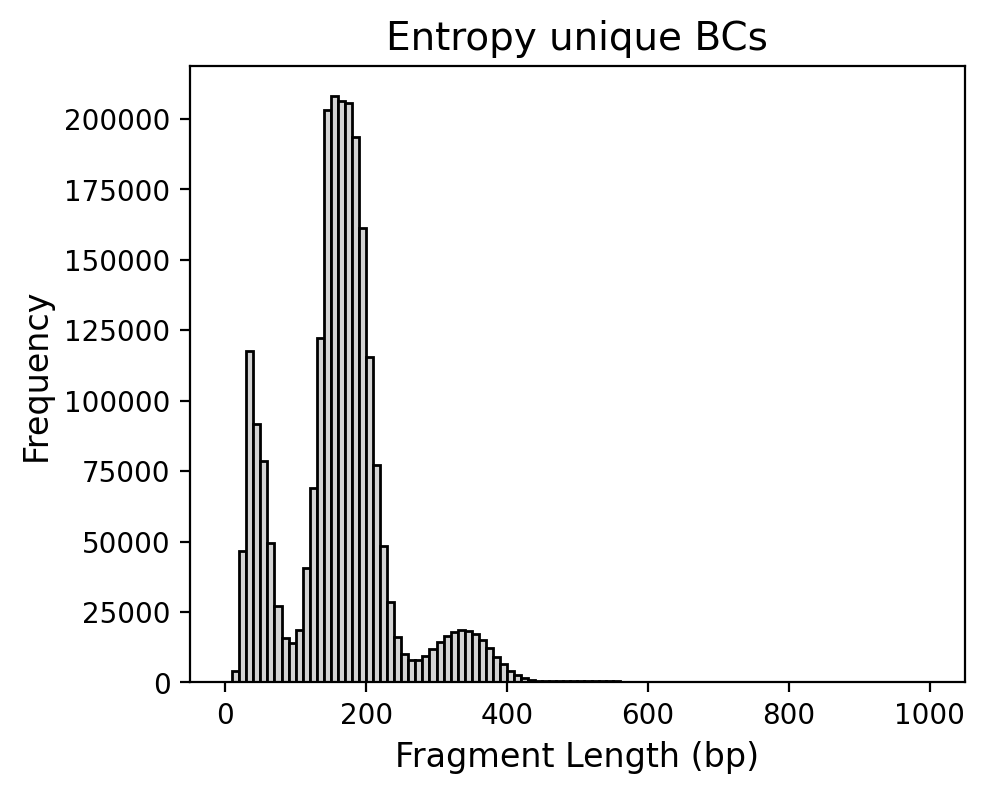

In [61]:

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( Entropy_unique_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Entropy unique BCs', fontsize=14)

## Between SADE & TSS

In [62]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only')
].index.values
TSS_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [63]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only'
].index.values
TSS_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [64]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

TSS_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

Text(0.5, 1.0, 'TSS unique BCs with invalid entropy values')

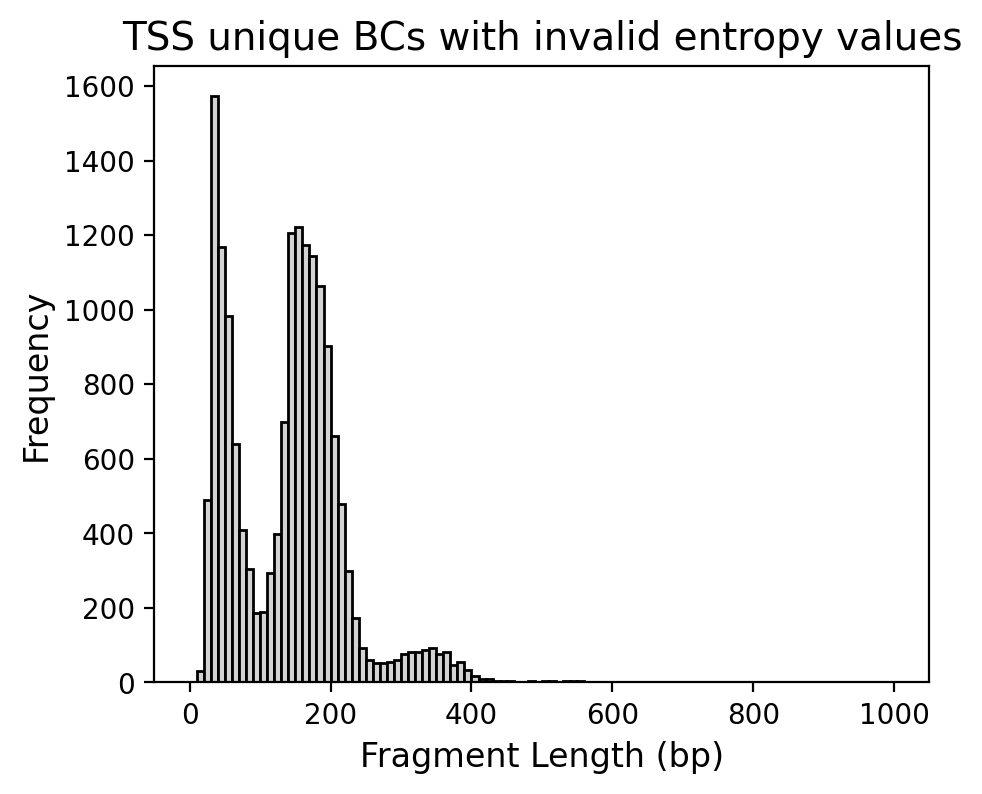

In [65]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( TSS_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('TSS unique BCs with invalid entropy values', fontsize=14)

Text(0.5, 1.0, 'TSS unique BCs with valid entropy values')

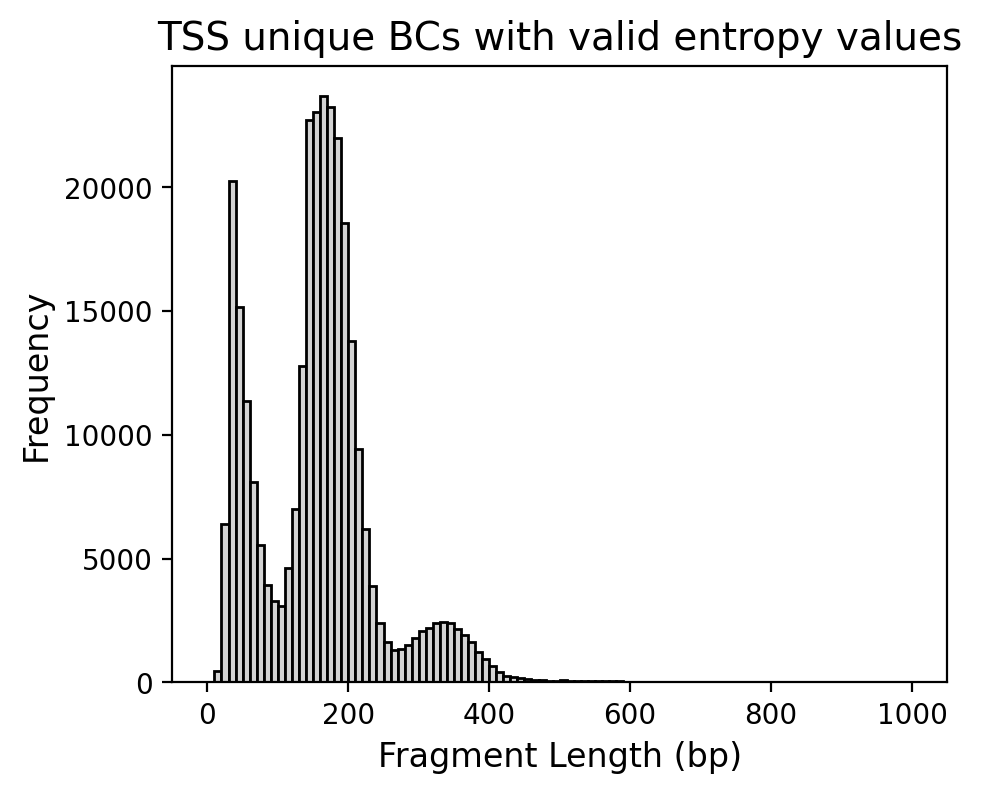

In [67]:

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( TSS_unique_validEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('TSS unique BCs with valid entropy values', fontsize=14)

# Calculate correlation with chromosome level fragment frequency

In [79]:
CRunique_chrom_counts = CR_unique_validEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Overlapped_chrom_counts = Overlap_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Entropyunique_chrom_counts = Entropy_unique_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)

for count in [CRunique_chrom_counts, Overlapped_chrom_counts, Entropyunique_chrom_counts]:
    # drop non-chromosome columns
    columns = [ col for col in count.columns if not col.startswith('chr') ]
    count.drop(columns=columns, inplace=True)

In [80]:
CRunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=CRunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in CRunique_BC_corr.columns:
    CRunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( CRunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [81]:
Entropyunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=Entropyunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in Entropyunique_BC_corr.columns:
    Entropyunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( Entropyunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [82]:
CRunique_BC_corr.head()

atac_bc,AAGCTAGGTTCTCACC,ACCTGGAAGAAAGGCA,ACGTCAACACGCCCAT,AGAATCTCATGAGCTA,ATAACCAAGTTAGGAC,ATGCGATAGTACTGAA,ATGTTGCGTAAGGCCG,ATGTTTGGTTTAATCG,CAAGTAATCTAACTGT,CAATGAGGTTTGGCTG,...,TAGCTAAAGCATCCTA,TATCCGGGTTATGGCT,TCAAACCGTAGGTGAC,TCAGGGATCCGCTAAC,TCCTGAGGTGGTTCTG,TCCTTTGGTTCCGGAC,TGATTGCGTCGGTTCA,TGGATCACAATTGACG,TGTTGCGGTAATTGGG,TTGAACCGTTCGGTAT
atac_bc,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,0.501159,0.878167,0.807948,0.897540,0.781836,0.911672,0.923540,0.771363,0.918147,0.764679,...,0.915989,0.879178,0.415422,0.325023,0.841162,0.733815,0.937424,0.725252,0.424223,0.748463
AAACAAGCATTTCTTC,0.075696,0.207193,0.417866,0.171815,0.140150,0.252068,0.105652,0.449896,0.205104,0.335927,...,0.021812,0.309582,0.115025,-0.090817,0.229183,0.103706,0.212866,0.033505,0.368569,0.032237
AAACCGCCAACGGTAC,0.440918,0.887922,0.794745,0.886531,0.777179,0.904097,0.915962,0.717528,0.893358,0.733507,...,0.922765,0.857136,0.418757,0.346276,0.802015,0.720874,0.913220,0.765421,0.318483,0.760677
AAACCGCCAGAAACCC,0.111379,0.699528,0.683647,0.607877,0.541515,0.829185,0.578455,0.650684,0.635250,0.575669,...,0.517794,0.682768,0.235588,0.290573,0.462284,0.491378,0.584195,0.608272,0.303695,0.484723
AAACGAACACCTGTAT,0.542016,0.898107,0.742021,0.881140,0.725180,0.911537,0.899886,0.827396,0.925291,0.821625,...,0.879963,0.940523,0.475428,0.313179,0.791095,0.773629,0.904714,0.798552,0.379159,0.761551


 ----- 	 CRunique 	 Entropyunique
Mean 	 0.7220 	 0.7977
Median 	 0.8091 	 0.9095


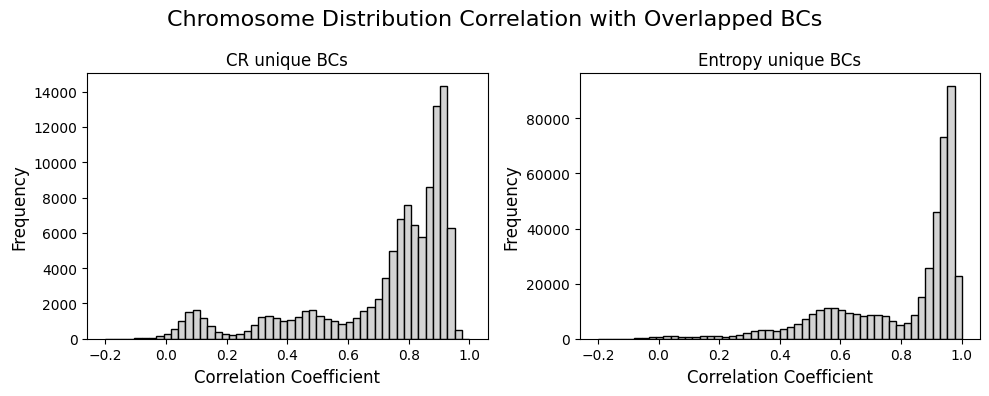

In [101]:
fig, ax = plt.subplots(ncols =2, figsize=(10, 4), sharey=False)

ax[0].hist( CRunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[0].set_xlabel('Correlation Coefficient', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('CR unique BCs')

ax[1].hist( Entropyunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[1].set_xlabel('Correlation Coefficient', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)
ax[1].set_title('Entropy unique BCs')
fig.suptitle('Chromosome Distribution Correlation with Overlapped BCs', fontsize=16)

fig.tight_layout()

mean_corr_CRunique = np.mean( CRunique_BC_corr.values.flatten() )
mean_corr_Entropyunique = np.mean( Entropyunique_BC_corr.values.flatten() )
median_corr_CRunique = np.median( CRunique_BC_corr.values.flatten() )
median_corr_Entropyunique = np.median( Entropyunique_BC_corr.values.flatten() )

print(f' ----- \t CRunique \t Entropyunique')
print(f'Mean \t {mean_corr_CRunique:.4f} \t {mean_corr_Entropyunique:.4f}')
print(f'Median \t {median_corr_CRunique:.4f} \t {median_corr_Entropyunique:.4f}')

/tmp/ipykernel_14837/3379117631.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[0].set_xticklabels(chrom_counts_1.columns, rotation=45)
/tmp/ipykernel_14837/3379117631.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[1].set_xticklabels(chrom_counts_2.columns, rotation=45)
/tmp/ipykernel_14837/3379117631.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[2].set_xticklabels(chrom_counts_3.columns, rotation=45)


(58, 24)


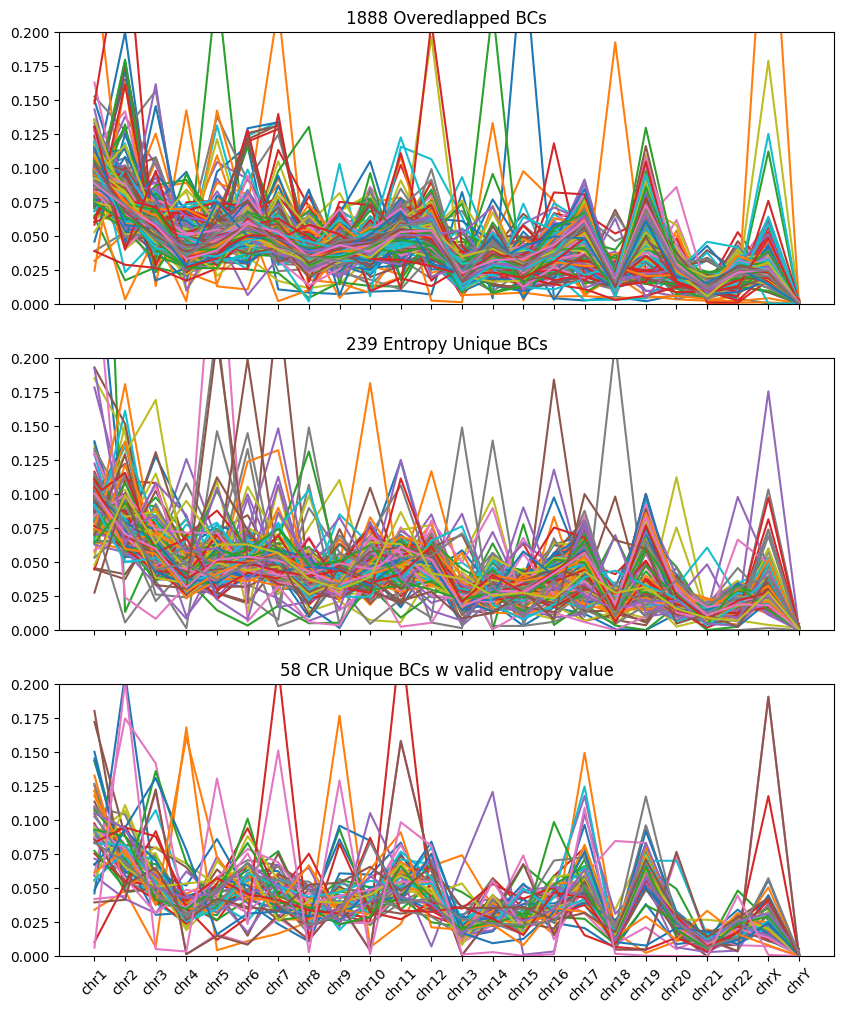

In [84]:
fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(10, 12), sharex=True)

chrom_counts_1 = Overlapped_chrom_counts.reindex( sorted(Overlapped_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts_1.iterrows():
    ax[0].plot( chrom_counts_1.columns, row / row.sum(),  )
ax[0].set_ylim(0, 0.2)
ax[0].set_title(f'{chrom_counts_1.shape[0]} Overedlapped BCs')
_ = ax[0].set_xticklabels(chrom_counts_1.columns, rotation=45)



chrom_counts_2 = Entropyunique_chrom_counts.reindex( sorted(Entropyunique_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

for idx, row in chrom_counts_2.iterrows():
    ax[1].plot( chrom_counts_2.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts_2.shape[0]} Entropy Unique BCs')
_ = ax[1].set_xticklabels(chrom_counts_2.columns, rotation=45)


chrom_counts_3 = CRunique_chrom_counts.reindex( sorted(CRunique_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)
print(chrom_counts_3.shape)

# line plot per barcode 
for idx, row in chrom_counts_3.iterrows():
    ax[2].plot( chrom_counts_3.columns, row / row.sum(),  )
    
ax[2].set_ylim(0, 0.2)
ax[2].set_title(f'{chrom_counts_3.shape[0]} CR Unique BCs w valid entropy value')
_ = ax[2].set_xticklabels(chrom_counts_3.columns, rotation=45)

/tmp/ipykernel_14837/3208045024.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)


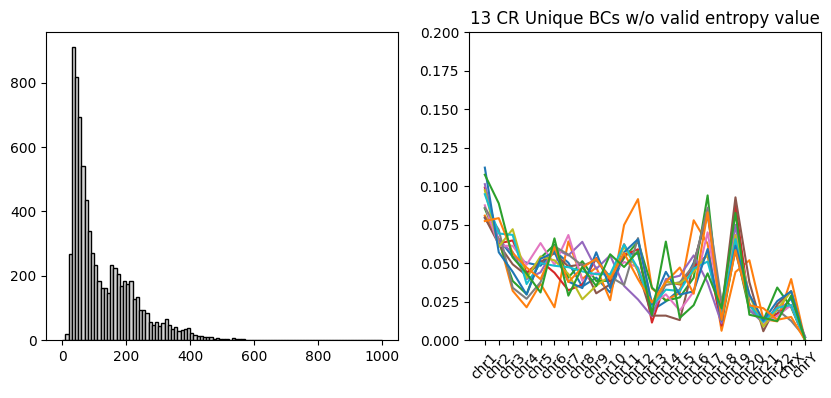

In [85]:
CRunique_noEntropy_chrom_counts = CR_unique_noEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
CRunique_noEntropy_chrom_counts = CRunique_noEntropy_chrom_counts.drop( columns=[ col for col in CRunique_noEntropy_chrom_counts.columns if not col.startswith('chr') ] )

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4) )

chrom_counts = CRunique_noEntropy_chrom_counts.reindex( sorted(CRunique_noEntropy_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts.iterrows():
    ax[1].plot( chrom_counts.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts.shape[0]} CR Unique BCs w/o valid entropy value')
_ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)

_ = ax[0].hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )

### Extension to TSS filtering

In [71]:
TSSunique_chrom_counts = TSS_unique_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)

for count in [ TSSunique_chrom_counts]:
    # drop non-chromosome columns
    columns = [ col for col in count.columns if not col.startswith('chr') ]
    count.drop(columns=columns, inplace=True)

/tmp/ipykernel_1959537/3838564510.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(chrom_counts_1.columns, rotation=45)


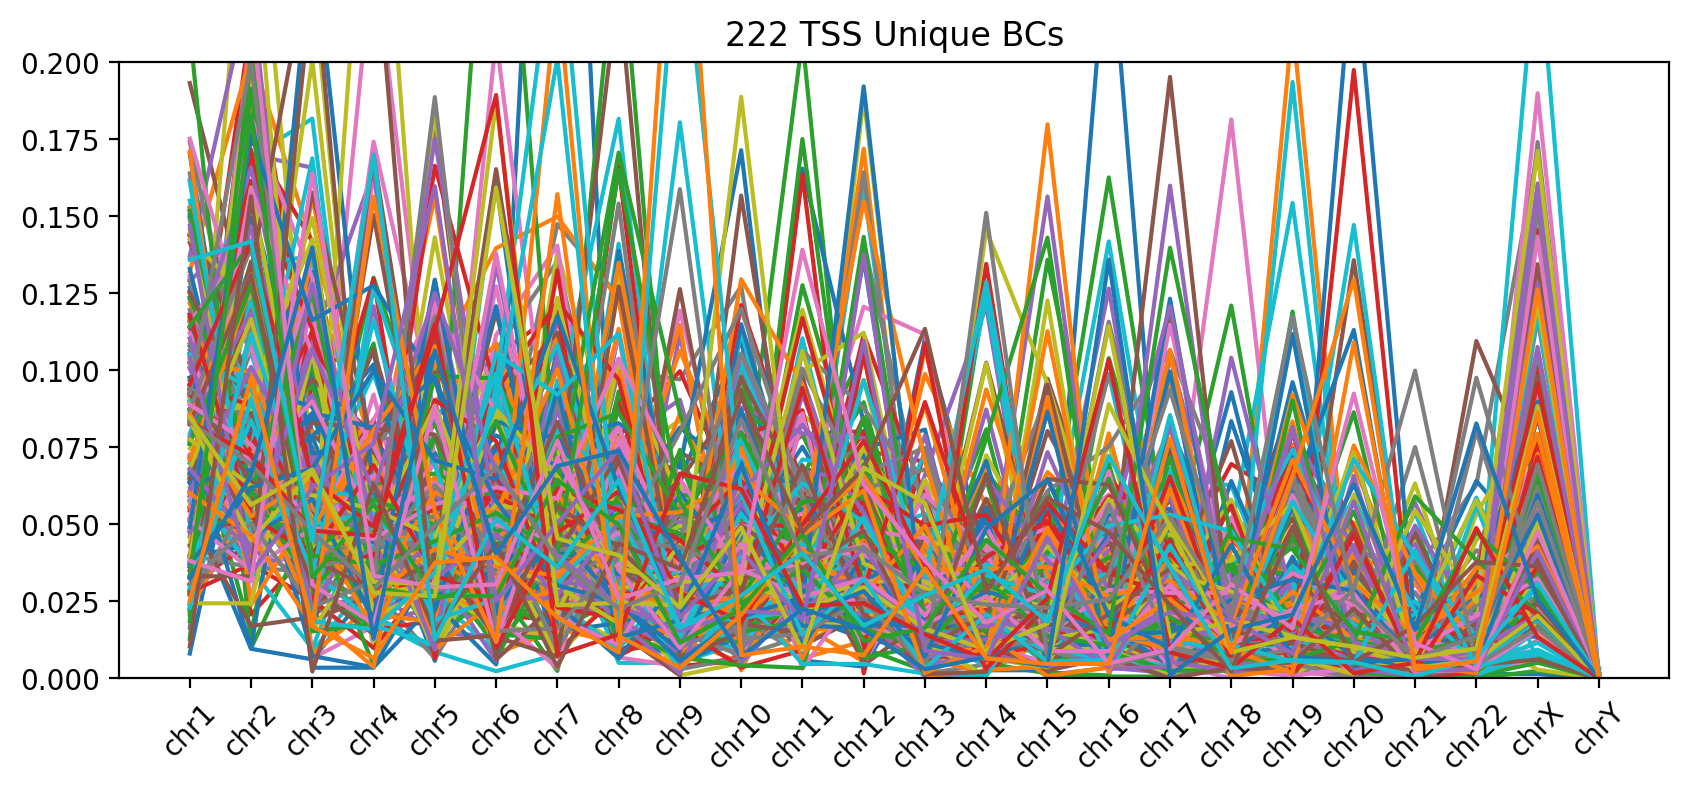

In [75]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 4),)

chrom_counts_1 = TSSunique_chrom_counts.reindex( sorted(TSSunique_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts_1.iterrows():
    ax.plot( chrom_counts_1.columns, row / row.sum(),  )
ax.set_ylim(0, 0.2)
ax.set_title(f'{chrom_counts_1.shape[0]} TSS Unique BCs')
_ = ax.set_xticklabels(chrom_counts_1.columns, rotation=45)